# Data Scientist Challenge

In this notebook we will explore different techniques to enhance model performance with limited labeled data.

In [ ]:
# SETUP

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import random
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer
import os
import json
from tqdm.auto import tqdm
from groq import Groq
from transformers import EarlyStoppingCallback
import os
import time
from scipy.special import softmax

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Define random seeds
def lock_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    set_seed(seed)

lock_seeds(7994)

In [ ]:
# Load data
df = pd.read_csv("../data/cleaned_sarcasm_dataset.csv")

# Train, test split
X_train = df[df['split']=='train']
X_test = df[df['split']=='test']

y_train = X_train[['label']]
y_test = X_test[['label']]

### a) BERT Model with Limited Data

In this section, we use a BERT-based model (DistilBERT) for our classification task, which involves the indentification of sarcasm in text. Notice that we use early stopping to prevent overtfitting.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10790.04it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 734/734 [00:00<00:00, 5317.22 examples/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib

Epoch,Training Loss,Validation Loss
1,0.888197,0.794258
2,0.598852,0.667230
3,0.573030,0.627673
4,0.617912,0.634153
5,0.491003,0.624619
6,0.453375,0.602577
7,0.400015,0.603491
8,0.442439,0.599894
9,0.507375,0.612913
10,0.556484,0.596135


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.93it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.87it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.68it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported o


DISTILBERT FEW-SHOT PERFORMANCE REPORT:
               precision    recall  f1-score   support

Non-Sarcastic       0.61      0.56      0.58       272
    Sarcastic       0.75      0.79      0.77       462

     accuracy                           0.70       734
    macro avg       0.68      0.67      0.68       734
 weighted avg       0.70      0.70      0.70       734



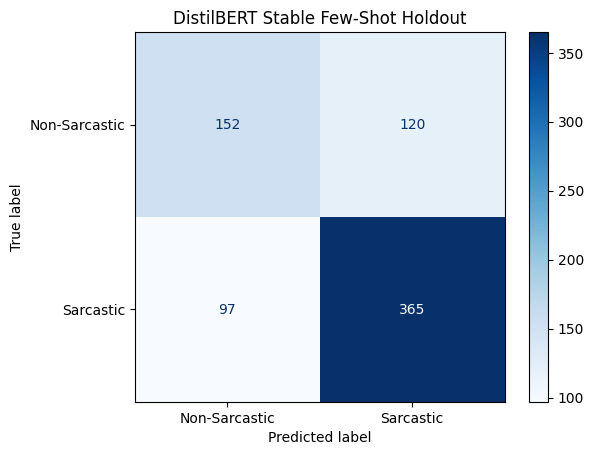

In [ ]:
# Set seed
set_seed(11)

# Target text column
text_col = 'Sentence'

# Create a balanced few-shot training set with 32 samples (16 per class)
df_few_shot = X_train.groupby('label').sample(n=16, random_state=749)
df_few_shot = df_few_shot.sample(frac=1, random_state=749).reset_index(drop=True)

# Copy the holdout dataset for validation
df_unseen = X_test.copy()

# Map string labels to uniform integers (0 = Non-Sarcastic, 1 = Sarcastic)
df_few_shot['labels'] = df_few_shot['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})
df_unseen['labels'] = df_unseen['label'].astype(str).str.strip().map({'Non-Sarcastic': 0, 'Sarcastic': 1})

# Drop old label columns
df_few_shot_clean = df_few_shot.drop(columns=['label'])
df_unseen_clean = df_unseen.drop(columns=['label'])

# Convert Pandas DataFrames into Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(df_few_shot_clean)
eval_dataset = Dataset.from_pandas(df_unseen_clean)

if '__index_level_0__' in train_dataset.column_names:
    train_dataset = train_dataset.remove_columns(['__index_level_0__'])
if '__index_level_0__' in eval_dataset.column_names:
    eval_dataset = eval_dataset.remove_columns(['__index_level_0__'])

# Load tokenizer and base model architecture
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Freeze transformer backbone
for param in model.distilbert.parameters():
    param.requires_grad = False

# Tokenization preprocessing function
def tokenize_function(examples):
    return tokenizer(examples[text_col], padding="max_length", truncation=True)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_eval = eval_dataset.map(tokenize_function, batched=True)

# Training arguments
training_args = TrainingArguments(
    output_dir="../results",
    num_train_epochs=15,
    learning_rate=5e-4,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    seed=7994,
    logging_steps=1,
)

# Initialize the Trainer pipeline
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,       
)

# Execute training loop
trainer.train()

# Generate model predictions on the unseen validation dataset
predictions = trainer.predict(tokenized_eval)
unseen_logits = predictions.predictions
unseen_true = predictions.label_ids
unseen_preds = np.argmax(unseen_logits, axis=-1)

# Print out classification metrics
print("\nDISTILBERT FEW-SHOT PERFORMANCE REPORT:")
print(classification_report(unseen_true, unseen_preds, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Plot the Confusion Matrix
cm_bert_unseen = confusion_matrix(unseen_true, unseen_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert_unseen, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues', values_format='d')
plt.title("DistilBERT Stable Few-Shot Holdout")
plt.show()

**Comments:** As we can see, we are using the same test and train partitions as in the part 1, in order to ensure that our results are comparable to the previous ones. Notice that, when we choose 32 labels from the train dataset, we are guguaranteeing that both classes are equally represented; choosing 16 examples of each class to train our BERT-based model. Regarding the chosen model, we have decided to use DistilBERT due the fact that it retains the high performance while being smaller in size when compared to other BERT-based models.

Regarding the implementation, first of all we freeze the entire model architecture and we only optimize the classification head. Moreovee, we define the number of training epochs as 15, which we consider to be sufficient for the classifier to perform well. Provided that we are only training the classification set, we use a larger learning rate than we would expect when fine-tuning the full network. A small batch size of 8 is optimal for this few-shot scenario to maximize the frequency of weight updates across our limited 32-sample training set. Finally, we instructed the model to load the best model at the end, to avoid the risk of overfitting during later epochs.

**Results:** By fine-tuning only the classification set of a DistilBERT model and with an extremely limited number of samples (32), we achieve a notable increase in performance when compared to that of the models presented in part 1. Notice how, in this case, accuracy has spiked to 0.6, and the macro F1-score sits at 0.68. Both the precision and the recall for the "Sarcastic" class (0.75 and 0.79, respectively) have increased significantly, which signals that our model performs satisfactorily in terms of true positives. However, the recall of the "Non-Sarcastic" class (0.56) shows how false positives still constitute a challenge for our model.

#### b) Dataset Augmentation

In this second exercise, we are going to experiment with an automated technique to increase our dataset size. As we have seen in part 1, sarcasm depends a lot on contrasting the sentiment of different parts of the sentence. following this premise, our augmentation technique cannot be involve diminishing the size of the sentences (keeping one part, for example), but rather, we have chosen to generate similar sentences by replacing some of the words by synonyms. As a result, we will generate 2 additional different sentences with the same meaning for each one of the 32 labelled examples.

Notice that, similarly to the previous section, we implement early stopping to prevent the model from overfitting.

In [116]:
# Function to replace words with a synonym in a sentece
def replace_with_synonyms(text, num_replacements=2):
    # If 0 replacements requested, return original
    if num_replacements == 0:
        return text
        
    # Isolate punctuation tokens
    words = word_tokenize(text)
    if len(words) < 3: 
        return text  
    
    # Filter for words
    valid_words = list(set([w for w in words if w.isalpha()]))
    random.shuffle(valid_words)
    
    replaced = 0
    for word in valid_words:
        syns = {l.name().replace('_', ' ').lower() for syn in wordnet.synsets(word) for l in syn.lemmas()}
        syns.discard(word.lower())
        
        if syns:
            words = [random.choice(list(syns)) if w == word else w for w in words]
            replaced += 1
            
        if replaced >= num_replacements:
            break
            
    # Reattaching punctuation
    return TreebankWordDetokenizer().detokenize(words)


new_rows = []

for _, row in df_few_shot_clean.iterrows():
    # Generate 2 variations per original sentence
    for _ in range(2):
        new_text = replace_with_synonyms(row['Sentence'], num_replacements=2)
        
        if new_text != row['Sentence']:
            new_rows.append({'Sentence': new_text, 'labels': row['labels']})

# Combine, drop duplicates, and merge
df_synthetic = pd.DataFrame(new_rows)
df_train_expanded = pd.concat([df_few_shot_clean, df_synthetic]).drop_duplicates().reset_index(drop=True)

print(f"Original Training Size: {len(df_few_shot_clean)}")
print(f"Expanded Training Size: {len(df_train_expanded)}")

Original Training Size: 32
Expanded Training Size: 96


As a result of the code above, we obtain an expanded training dataset that includes the 32 original samples, together with 2 variations for each one of them; increasing the training size to 96 sentences. Next, we train the DistilBERT model with the very same hyperparameters that we detailed in the previous section, but with the newly expanded training datatset. Notice that, as we did before, we are freezing the model backbone, and only training the classification head. 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9960.11it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 96/96 [00:00<00:00, 4293.55 examples/s]


Training Augmented Model from scratch...


Epoch,Training Loss,Validation Loss
1,0.620471,0.667752
2,0.620323,0.586580
3,0.514162,0.609541
4,0.239846,0.588987
5,0.308140,0.620644


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.68it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.63it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.32it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported o


Evaluating against the exact same holdout set...


/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



--- Model B (Augmented) Results ---
               precision    recall  f1-score   support

Non-Sarcastic       0.66      0.50      0.57       272
    Sarcastic       0.74      0.85      0.79       462

     accuracy                           0.72       734
    macro avg       0.70      0.67      0.68       734
 weighted avg       0.71      0.72      0.71       734



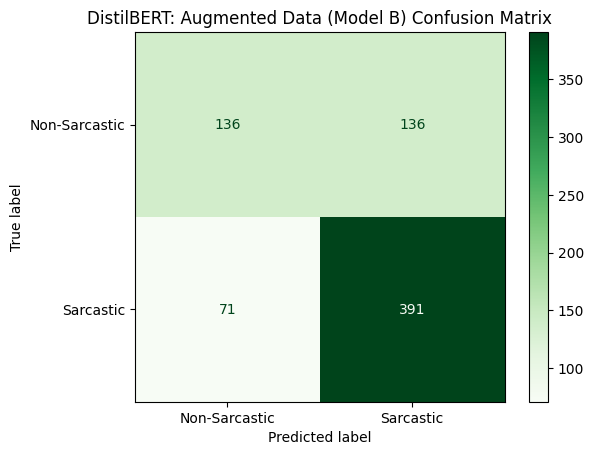

In [129]:
# DistilBERT model initialization
model_name = "distilbert-base-uncased"
fresh_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Tokenize the new expanded dataset
expanded_dataset = Dataset.from_pandas(df_train_expanded)
if '__index_level_0__' in expanded_dataset.column_names:
    expanded_dataset = expanded_dataset.remove_columns(['__index_level_0__'])

# Freeze architecture
for param in fresh_model.distilbert.parameters():
    param.requires_grad = False

tokenized_expanded_train = expanded_dataset.map(tokenize_function, batched=True)

# Trainer with the exact same hyperparameters
training_args = TrainingArguments(
    output_dir="../results_augmented",
    num_train_epochs=15,
    learning_rate=5e-4,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    seed=7994,
    logging_steps=1,
)

# Initialize the Trainer pipeline
trainer_augmented = Trainer(
    model=fresh_model,
    args=training_args,
    train_dataset=tokenized_expanded_train,
    eval_dataset=tokenized_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train and Evaluate
print("Training Augmented Model from scratch...")
trainer_augmented.train()

print("\nEvaluating against the exact same holdout set...")
predictions_aug = trainer_augmented.predict(tokenized_eval)

# Print the final results
unseen_preds_aug = np.argmax(predictions_aug.predictions, axis=-1)
print("\n--- Model B (Augmented) Results ---")
print(classification_report(predictions_aug.label_ids, unseen_preds_aug, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Confusion matrix
cm_aug = confusion_matrix(predictions_aug.label_ids, unseen_preds_aug)

disp_aug = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug, 
    display_labels=['Non-Sarcastic', 'Sarcastic']
)

disp_aug.plot(cmap='Greens', values_format='d')

plt.title("DistilBERT: Augmented Data (Model B) Confusion Matrix")
plt.show()

As can be observed by the classification metrics that we have reported above and by the confusion matrix, and in general terms, the DistilBERT model with the 96-sample training dataset (with the 32 original sentences and the 64 additional ones that we have generated) performs well. The macro F1-score (0.68) remains the same as in section a, but accuracy has increased 0.02 from 0.7 to 0.72. This increase can be traced back to the fact that the recall for the "Sarcastic" class has increased, and the precision for "Non-Sarcastic" has increased as well. The recall for the "Non-Sarcastic" class has dropped by 0.06, which is nonetheless compensated by an equivalent increase in precision in the "Non-Sarcastic" class, as we have just presented.

In the code below, we implement an algorithm that optimizes the number of words to replace in each of the new sentences generated. Notice that we only test with up to 10 words to replace because of the EDA, which showed that that's the minimum length of some sentences.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9034.97it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 96/96 [00:00<00:00, 5424.62 examples/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/py

Epoch,Training Loss,Validation Loss
1,0.651318,0.681943
2,0.583067,0.590496
3,0.527485,0.611436
4,0.240948,0.587673
5,0.324015,0.623354
6,0.213277,0.624231
7,0.219149,0.632613


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.69it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.63it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.24it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported o

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7918.26it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 96/96 [00:00<00:00, 6351.70 examples/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/py

Epoch,Training Loss,Validation Loss
1,0.629176,0.680384
2,0.621056,0.589148
3,0.507399,0.616496
4,0.261654,0.591229
5,0.320475,0.631275


...

Epoch,Training Loss,Validation Loss
1,0.655372,0.681864
2,0.570012,0.596955
3,0.517253,0.602052
4,0.257310,0.592165
5,0.363918,0.623481
6,0.238406,0.621529
7,0.210936,0.626978


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.13it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.02it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.07it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported o

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7822.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 96/96 [00:00<00:00, 6993.91 examples/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/py

Epoch,Training Loss,Validation Loss
1,0.677313,0.688529
2,0.645017,0.595443
3,0.580801,0.614713
4,0.281847,0.575874
5,0.381870,0.618242
6,0.334629,0.593067
7,0.328282,0.622824


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.41it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.93it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 12.45it/s]
/Users/eric/Desktop/work/02_bse/t3_advanced-nlp/sarcasm_text_classification/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported o

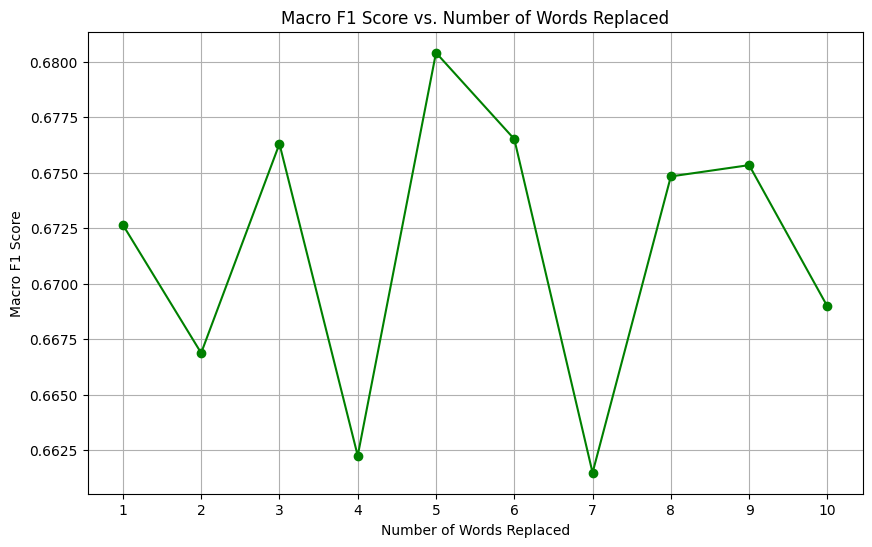


--- Optimal Model B (Augmented - 5 Words) Results ---
               precision    recall  f1-score   support

Non-Sarcastic       0.59      0.63      0.61       272
    Sarcastic       0.77      0.74      0.75       462

     accuracy                           0.70       734
    macro avg       0.68      0.68      0.68       734
 weighted avg       0.70      0.70      0.70       734



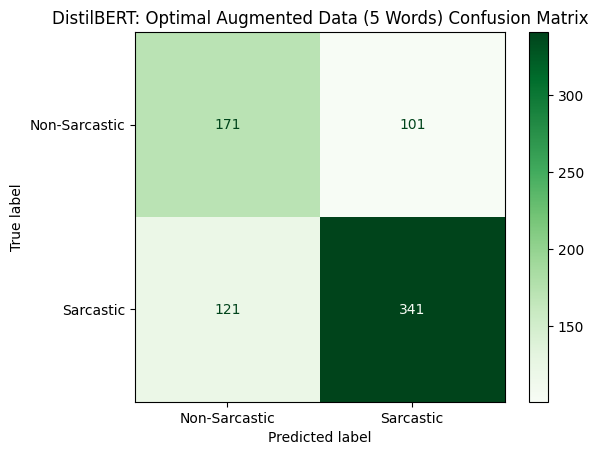

In [142]:
macro_f1_scores = []
best_f1 = -1
best_num_words = 0
best_label_ids = None
best_preds = None

# Loop over the number of words to replace
for num_words in range(1, 11):
    
    new_rows = []
    for _, row in df_few_shot_clean.iterrows():
        for _ in range(2):
            new_text = replace_with_synonyms(row['Sentence'], num_replacements=num_words)
            if new_text != row['Sentence']:
                new_rows.append({'Sentence': new_text, 'labels': row['labels']})

    df_synthetic = pd.DataFrame(new_rows)
    df_train_expanded = pd.concat([df_few_shot_clean, df_synthetic]).drop_duplicates().reset_index(drop=True)

    # For each specification, fine-tune the DistilBERT
    model_name = "distilbert-base-uncased"
    fresh_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    expanded_dataset = Dataset.from_pandas(df_train_expanded)
    if '__index_level_0__' in expanded_dataset.column_names:
        expanded_dataset = expanded_dataset.remove_columns(['__index_level_0__'])

    for param in fresh_model.distilbert.parameters():
        param.requires_grad = False

    tokenized_expanded_train = expanded_dataset.map(tokenize_function, batched=True)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"../results_augmented_{num_words}",
        num_train_epochs=15,
        learning_rate=5e-4,
        per_device_train_batch_size=8,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        seed=7994,
        logging_steps=1
    )

    # Trainer
    trainer_augmented = Trainer(
        model=fresh_model,
        args=training_args,
        train_dataset=tokenized_expanded_train,
        eval_dataset=tokenized_eval,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer_augmented.train()

    predictions_aug = trainer_augmented.predict(tokenized_eval)

    unseen_preds_aug = np.argmax(predictions_aug.predictions, axis=-1)
    
    # Save Macro F1-score to list for comparison
    current_f1 = f1_score(predictions_aug.label_ids, unseen_preds_aug, average='macro', zero_division=0)
    macro_f1_scores.append(current_f1)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_num_words = num_words
        best_label_ids = predictions_aug.label_ids
        best_preds = unseen_preds_aug

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), macro_f1_scores, marker='o', linestyle='-', color='g')
plt.title("Macro F1 Score vs. Number of Words Replaced")
plt.xlabel("Number of Words Replaced")
plt.ylabel("Macro F1 Score")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print(f"\n--- Optimal Model B (Augmented - {best_num_words} Words) Results ---")
print(classification_report(best_label_ids, best_preds, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Confusion matrix
cm_aug = confusion_matrix(best_label_ids, best_preds)

disp_aug = ConfusionMatrixDisplay(
    confusion_matrix=cm_aug, 
    display_labels=['Non-Sarcastic', 'Sarcastic']
)

disp_aug.plot(cmap='Greens', values_format='d')

plt.title(f"DistilBERT: Optimal Augmented Data ({best_num_words} Words) Confusion Matrix")
plt.show()

As we can see from the classification metrics the we have presented above, as well as the confusion matrix, the overall performance of the optimized model (with number of words to replace = 5) is identical to that of the initial model with 2 words to be replaced, both with a 0.68 macro F1-score. However, we observe a shift in the dynamics of the model, as the latter performs better for the "Sarcastic" class, whereas the former appears to be better for the "Non-Sarcastic" class, suggesting that replacing more words by it's synonyms confuses the model when the ground truth is "Sarcastic", making them appear to be "Non-Sarcastic".

Provided that the optimization process has not resulted in a better performance, when mentioning model b we will refering to the previous, non-optimized, model that we presented above.

### c) Zero-Shot Learning with LLM

In this section, we implement Zero-Shot Learning with LLMs. Specifically, we use Meta's Llama 3.1 model, which has 8 billion parameters. We selected this model because it handles binary classification and strict JSON formatting, while bypassing the API rate limits of larger models (such as Llama 3.3 70B). Notice that we subsample and test on 50% of the data to overcome token limitation in the LLM models. Additionally, we keep the temperature at 0 provided that we implement a classification task, which requires of low values for temperature so that the probabilities of the returned word are more extreme.

Evaluating 367 examples with Groq (Llama 3.3 70B)...


Groq Zero-Shot: 100%|██████████| 367/367 [12:18<00:00,  2.01s/it]


--- Part C: Groq (Llama 3.3) Zero-Shot Performance ---
               precision    recall  f1-score   support

Non-Sarcastic       0.78      0.30      0.43       127
    Sarcastic       0.72      0.95      0.82       240

     accuracy                           0.73       367
    macro avg       0.75      0.63      0.63       367
 weighted avg       0.74      0.73      0.69       367



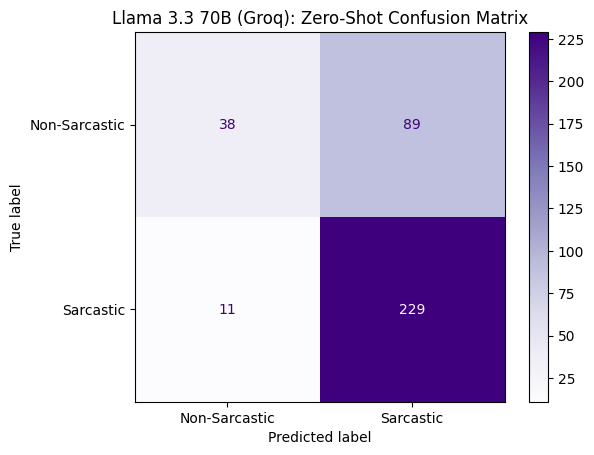

In [ ]:
# Initialize Groq, Add Groq api key to run
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
client = Groq()

# We subsample and test on 50% of the test data to overcome token limitations
df_zero_shot_test = df_unseen.sample(int(len(df_unseen)/2)).reset_index(drop=True)

# Helper function for Zero-Shot LLM prediction.
# Sends a single sentence to Groq and strictly extracts a 0 or 1 prediction using JSON mode
def zero_shot_predict_groq(text):
    prompt = f"""
    You are an expert linguistic AI specialized in recognizing pragmatics and nuance.
    Analyze the following sentence and determine if it contains sarcasm.
    
    Sentence: "{text}"
    
    Respond strictly in JSON format with a single key "prediction" containing either the integer 1 (Sarcastic) or 0 (Non-Sarcastic). Do not include explanations.
    """
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "user", "content": prompt}
            ],
            temperature=0.0, # Enforces determinism 
            response_format={"type": "json_object"} # Forces the output into parsable JSON
        )
        
        # Parse the structured JSON response
        result = json.loads(response.choices[0].message.content)
        return result.get("prediction", 0)
        
    except Exception as e:
        print(f"API Error: {e}")
        return 0 

# Run the evaluation loop
print(f"Evaluating {len(df_zero_shot_test)} examples with Groq (Llama 3.1 8B)...")
groq_preds = []
true_labels = df_zero_shot_test['labels'].tolist()

for sentence in tqdm(df_zero_shot_test['Sentence'], desc="Groq Zero-Shot"):
    pred = zero_shot_predict_groq(sentence)
    groq_preds.append(pred)

# Generate final metrics
print("\n--- Part C: Groq (Llama 3.1) Zero-Shot Performance ---")
print(classification_report(true_labels, groq_preds, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Plot Confusion Matrix
cm_groq = confusion_matrix(true_labels, groq_preds)
disp_groq = ConfusionMatrixDisplay(confusion_matrix=cm_groq, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp_groq.plot(cmap='Purples', values_format='d')
plt.title("Llama 3.1 8B (Groq): Zero-Shot Confusion Matrix")
plt.show()

By applying an LLM in a zero-shot learning setup, we have not been able to yield a better-performing model than those presented in models a or b. In general terms, this latest model overwhelmingly predicts "Sarcastic", which translates into a great improvement in the recall of the "Sarcastic" class, at the expense of a worsening in precision and both precision and recall for the "Non-Sarcastic" class.

### d) Data Generation with LLM

In this section, we use an LLM (Meta's Llama 3.1) to generate new labeled data. In other terms, we aim at leveraging LLMs to generate 100 new sentences (50 for each class), which we will use later on to train our DistilBERT model. Notice that we have increased the temperature up to 0.7 to obtain moderately more creative responses.

In [ ]:
TOTAL_NEEDED = 100
BATCH_SIZE = 10
all_synthetic_data = []

# Loop over the batches
for _ in tqdm(range(TOTAL_NEEDED // BATCH_SIZE), desc="Generating Data"):
    prompt = f"""
    Generate exactly {BATCH_SIZE} highly diverse synthetic sentences. 
    Half should be sarcastic (label 1), half non-sarcastic (label 0).
    Respond strictly in JSON format matching this exact schema:
    {{
        "data": [
            {{"labels": 1, "Sentence": "Example sarcastic sentence."}},
            {{"labels": 0, "Sentence": "Example non-sarcastic sentence."}}
        ]
    }}
    """

    # Set 5 retries max
    retries = 0
    while retries < 5:
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
                response_format={"type": "json_object"}
            )
            
            raw_response = response.choices[0].message.content
            result_json = json.loads(raw_response)
            batch_data = result_json.get("data")
            
            if batch_data is not None:
                all_synthetic_data.extend(batch_data)
                break
            else:
                retries += 1
                
        except Exception as e:
            error_str = str(e)
            if "429" in error_str or "rate limit" in error_str.lower():
                time.sleep(60)
            else:
                time.sleep(2)
                retries += 1

df_synthetic = pd.DataFrame(all_synthetic_data)

if not df_synthetic.empty:
    df_synthetic = df_synthetic.drop_duplicates(subset=['Sentence'])

print(f"Successfully generated {len(df_synthetic)} unique rows!")

Generating Data: 100%|██████████| 10/10 [00:05<00:00,  1.82it/s]

Successfully generated 99 unique rows!


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9428.37it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 131/131 [00:00<00:00, 6320.57 examples/s]


Training DistilBERT on LLM-Generated data from scratch...


Epoch,Training Loss,Validation Loss
1,0.573590,0.653139
2,0.615390,0.598469
3,0.412463,0.577288
4,0.414164,0.580905
5,0.080485,0.610919
6,0.209482,0.600273


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.51it/s]



Evaluating against the exact same test holdout set...



--- Model D (LLM Data Generation) Results ---
               precision    recall  f1-score   support

Non-Sarcastic       0.64      0.34      0.44       272
    Sarcastic       0.69      0.89      0.78       462

     accuracy                           0.68       734
    macro avg       0.67      0.61      0.61       734
 weighted avg       0.67      0.68      0.65       734



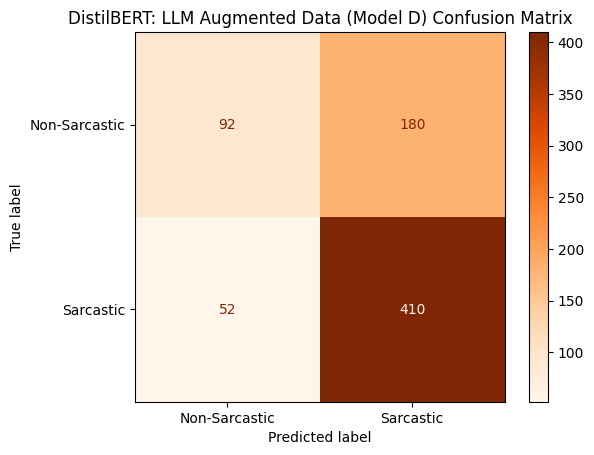

In [ ]:
set_seed(11)

# Concat the newly generated sentences and the original 32-sample dataset
df_llm_augmented = pd.concat([df_few_shot_clean, df_synthetic]).drop_duplicates()

model_name = "distilbert-base-uncased"
fresh_model_d = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Freeze transformer architecture
for param in fresh_model_d.distilbert.parameters():
    param.requires_grad = False

# Tokenize the LLM Augmented Dataset
llm_dataset = Dataset.from_pandas(df_llm_augmented)
if '__index_level_0__' in llm_dataset.column_names:
    llm_dataset = llm_dataset.remove_columns(['__index_level_0__'])

tokenized_llm_train = llm_dataset.map(tokenize_function, batched=True)

# Trainer setup
training_args_d = TrainingArguments(
    output_dir="../results_llm_augmented",
    num_train_epochs=15,             
    learning_rate=5e-4,           
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",             
    dataloader_pin_memory=False,    
    remove_unused_columns=True,
    load_best_model_at_end=True,
    metric_for_best_model='loss',
    seed=7994,
    logging_steps=1
)

# Trainer
trainer_llm = Trainer(
    model=fresh_model_d,              
    args=training_args_d,
    train_dataset=tokenized_llm_train, 
    eval_dataset=tokenized_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train and Evaluate
print("Training DistilBERT on LLM-Generated data from scratch...")
trainer_llm.train()

print("\nEvaluating against the exact same test holdout set...")
predictions_d = trainer_llm.predict(tokenized_eval)

# Metrics Report
unseen_preds_d = np.argmax(predictions_d.predictions, axis=-1)
print("\n--- Model D (LLM Data Generation) Results ---")
print(classification_report(predictions_d.label_ids, unseen_preds_d, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Plot
cm_d = confusion_matrix(predictions_d.label_ids, unseen_preds_d)
disp_d = ConfusionMatrixDisplay(confusion_matrix=cm_d, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp_d.plot(cmap='Oranges', values_format='d') 
plt.title("DistilBERT: LLM Augmented Data (Model D) Confusion Matrix")
plt.show()

By generating data with LLMs (Meta's Llama 3.1), we have achieved a macro F1-score of 0.61, which is significantly worse than that of models a, b, and c. Regarding the "Sarcastic" class, it performs in-line with the pervious models, with a recall of 0.89; correctly identifying almost all of the sentences in the class. Additionally, and especially when compared to models a and b, the precision for this class has also decreased. As for the "Non-Sarcastic" class, it is where we find a worsening in the performance; fueled by a drop in the recall (that reaches 0.34).

### e. Optimal Technique Application

In this last section, we are going to apply the most effective techniques with have found throughout this part, in order to generate an improved model. To sum up, we have seen that only dataset augmentation achieves the same performance as our base modelm with Zero-Shot learning and data generation with LLMs perfomring slightly worse. Based on this, regarding the data, we will only use the sentences obtained from dataset augmentation, as we understand that the ones generated by LLMs are confusing the model. On the other hand, even though Zero-Shot learning with LLMs has proven to not perform as satisfactorily as our base model, we believe that it could be helpful for those sentences where the BERT model is unsure (which we set at a 50% threshold).

Master Training Dataset Size (Few-Shot + Synonyms + LLM): 96


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13511.71it/s]


{'loss': '0.6753', 'grad_norm': '1.207', 'learning_rate': '0.0005', 'epoch': '0.08333'}
{'loss': '0.6995', 'grad_norm': '1.633', 'learning_rate': '0.0004972', 'epoch': '0.1667'}
{'loss': '0.6611', 'grad_norm': '1.982', 'learning_rate': '0.0004944', 'epoch': '0.25'}
{'loss': '0.7065', 'grad_norm': '1.31', 'learning_rate': '0.0004917', 'epoch': '0.3333'}
{'loss': '0.8697', 'grad_norm': '3.455', 'learning_rate': '0.0004889', 'epoch': '0.4167'}
{'loss': '0.754', 'grad_norm': '2.286', 'learning_rate': '0.0004861', 'epoch': '0.5'}
{'loss': '0.658', 'grad_norm': '1.08', 'learning_rate': '0.0004833', 'epoch': '0.5833'}
{'loss': '0.6643', 'grad_norm': '1.347', 'learning_rate': '0.0004806', 'epoch': '0.6667'}
{'loss': '0.6007', 'grad_norm': '1.075', 'learning_rate': '0.0004778', 'epoch': '0.75'}
{'loss': '0.6653', 'grad_norm': '1.571', 'learning_rate': '0.000475', 'epoch': '0.8333'}
{'loss': '0.5524', 'grad_norm': '1.262', 'learning_rate': '0.0004722', 'epoch': '0.9167'}
{'loss': '0.7004', 'grad

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.74it/s]


{'loss': '0.6166', 'grad_norm': '1.144', 'learning_rate': '0.0004667', 'epoch': '1.083'}
{'loss': '0.5367', 'grad_norm': '0.991', 'learning_rate': '0.0004639', 'epoch': '1.167'}
{'loss': '0.5658', 'grad_norm': '1.061', 'learning_rate': '0.0004611', 'epoch': '1.25'}
{'loss': '0.6075', 'grad_norm': '1.326', 'learning_rate': '0.0004583', 'epoch': '1.333'}
{'loss': '0.5043', 'grad_norm': '1.157', 'learning_rate': '0.0004556', 'epoch': '1.417'}
{'loss': '0.5102', 'grad_norm': '1.068', 'learning_rate': '0.0004528', 'epoch': '1.5'}
{'loss': '0.6982', 'grad_norm': '4.04', 'learning_rate': '0.00045', 'epoch': '1.583'}
{'loss': '0.6993', 'grad_norm': '2.317', 'learning_rate': '0.0004472', 'epoch': '1.667'}
{'loss': '0.5767', 'grad_norm': '1.112', 'learning_rate': '0.0004444', 'epoch': '1.75'}
{'loss': '0.4736', 'grad_norm': '1.751', 'learning_rate': '0.0004417', 'epoch': '1.833'}
{'loss': '0.5596', 'grad_norm': '1.717', 'learning_rate': '0.0004389', 'epoch': '1.917'}
{'loss': '0.6461', 'grad_nor

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 12.52it/s]


{'loss': '0.2434', 'grad_norm': '0.848', 'learning_rate': '0.0003', 'epoch': '6.083'}
{'loss': '0.1767', 'grad_norm': '0.799', 'learning_rate': '0.0002972', 'epoch': '6.167'}
{'loss': '0.2973', 'grad_norm': '1.907', 'learning_rate': '0.0002944', 'epoch': '6.25'}
{'loss': '0.1369', 'grad_norm': '0.6031', 'learning_rate': '0.0002917', 'epoch': '6.333'}
{'loss': '0.3215', 'grad_norm': '1.095', 'learning_rate': '0.0002889', 'epoch': '6.417'}
{'loss': '0.1684', 'grad_norm': '1.327', 'learning_rate': '0.0002861', 'epoch': '6.5'}
{'loss': '0.228', 'grad_norm': '1.281', 'learning_rate': '0.0002833', 'epoch': '6.583'}
{'loss': '0.192', 'grad_norm': '1.268', 'learning_rate': '0.0002806', 'epoch': '6.667'}
{'loss': '0.2386', 'grad_norm': '1.857', 'learning_rate': '0.0002778', 'epoch': '6.75'}
{'loss': '0.1674', 'grad_norm': '0.8654', 'learning_rate': '0.000275', 'epoch': '6.833'}
{'loss': '0.2057', 'grad_norm': '0.8862', 'learning_rate': '0.0002722', 'epoch': '6.917'}
{'loss': '0.3919', 'grad_nor

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.97it/s]

{'train_runtime': '126.7', 'train_samples_per_second': '11.37', 'train_steps_per_second': '1.421', 'train_loss': '0.427', 'epoch': '7'}



--- Model E (Hybrid Cascade: DistilBERT + Llama 3.1 8B) Results ---
               precision    recall  f1-score   support

Non-Sarcastic       0.59      0.58      0.58       272
    Sarcastic       0.75      0.76      0.76       462

     accuracy                           0.69       734
    macro avg       0.67      0.67      0.67       734
 weighted avg       0.69      0.69      0.69       734



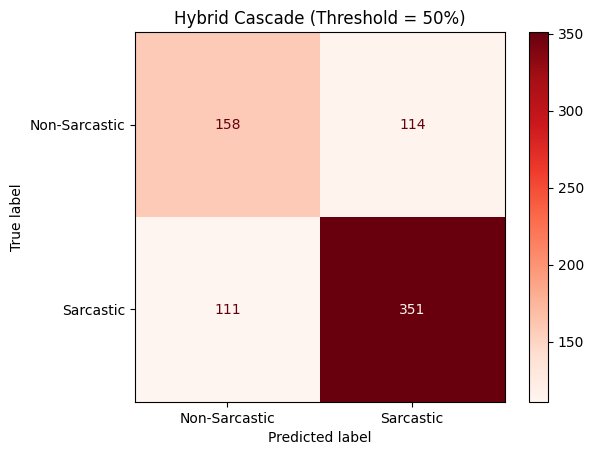

In [ ]:
# Silence environment warnings
import warnings
from transformers import logging as hf_logging
from datasets.utils.logging import disable_progress_bar
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
disable_progress_bar()

# Reproducibility
set_seed(11)

# Add Groq api key to run
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
client = Groq()

# Setup confidence threshold
CONFIDENCE_THRESHOLD = 0.5

# Train the DistilBERT model
df_master_train = pd.concat([df_train_expanded, df_synthetic]).drop_duplicates(subset=['Sentence']).reset_index(drop=True)
print(f"Master Training Dataset Size (Few-Shot + Synonyms + LLM): {len(df_master_train)}")

master_dataset = Dataset.from_pandas(df_master_train)
if '__index_level_0__' in master_dataset.column_names:
    master_dataset = master_dataset.remove_columns(['__index_level_0__'])

tokenized_master_train = master_dataset.map(tokenize_function, batched=True)

model_name = "distilbert-base-uncased"
master_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Freeze backbone architecture
for param in master_model.distilbert.parameters():
    param.requires_grad = False

# Training arguments
training_args_master = TrainingArguments(
    output_dir="../results_master_hybrid",
    num_train_epochs=15,
    learning_rate=5e-4,
    per_device_train_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    seed=7994,
    logging_steps=1,
)

# Trainer
trainer_master = Trainer(
    model=master_model,
    args=training_args_master,
    train_dataset=tokenized_master_train,
    eval_dataset=tokenized_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # <-- Re-added Early Stopping
)

trainer_master.train()
predictions_out = trainer_master.predict(tokenized_eval)
probs = softmax(predictions_out.predictions, axis=1)

final_predictions = []
uncertain_indices = []
uncertain_sentences = []

# Probability logic
for i, (prob_array, sentence) in enumerate(zip(probs, df_unseen['Sentence'])):
    max_prob = np.max(prob_array)
    pred_class = np.argmax(prob_array)
    
    if max_prob >= CONFIDENCE_THRESHOLD:
        final_predictions.append(pred_class)
    else:
        final_predictions.append(-1)
        uncertain_indices.append(i)
        uncertain_sentences.append(sentence)

# LLM fallback
def hybrid_batch_predict(sentences_batch):
    formatted_sentences = "\n".join([f"ID {i}: \"{text}\"" for i, text in enumerate(sentences_batch)])
    prompt = f"""
    Analyze this batch of sentences and determine if each contains sarcasm.
    Sentences:
    {formatted_sentences}
    Respond strictly in JSON format matching this schema: {{"results": [0, 1, 0...]}}
    The list must contain exactly {len(sentences_batch)} integers in order. Use 1 for Sarcastic and 0 for Non-Sarcastic.
    """
    
    retries = 0
    while retries < 3:
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                response_format={"type": "json_object"}
            )
            predictions = json.loads(response.choices[0].message.content).get("results", [])
            
            if len(predictions) == len(sentences_batch):
                return predictions
            else:
                return (predictions + [0] * len(sentences_batch))[:len(sentences_batch)]
        
        # Exception
        except Exception as e:
            error_str = str(e)
            if "429" in error_str or "rate limit" in error_str.lower():
                print(f"\n[Rate Limit] Sleeping for 60s...")
                time.sleep(60)
            else:
                time.sleep(2)
            retries += 1
            
    return [0] * len(sentences_batch) # Absolute fallback if Groq completely fails

groq_preds = []
BATCH_SIZE = 15

# Only process if there are uncertain sentences
if len(uncertain_sentences) > 0:
    for i in tqdm(range(0, len(uncertain_sentences), BATCH_SIZE), desc="Groq Fallback Processing"):
        batch = uncertain_sentences[i:i + BATCH_SIZE]
        batch_preds = hybrid_batch_predict(batch)
        groq_preds.extend(batch_preds)

for idx_in_unseen, groq_pred in zip(uncertain_indices, groq_preds):
    final_predictions[idx_in_unseen] = groq_pred

# Performance report
true_labels = predictions_out.label_ids

print("\n--- Model E (Hybrid Cascade: DistilBERT + Llama 3.1 8B) Results ---")
print(classification_report(true_labels, final_predictions, target_names=['Non-Sarcastic', 'Sarcastic'], zero_division=0))

# Confusion matrix
cm_hybrid = confusion_matrix(true_labels, final_predictions)
disp_hybrid = ConfusionMatrixDisplay(confusion_matrix=cm_hybrid, display_labels=['Non-Sarcastic', 'Sarcastic'])
disp_hybrid.plot(cmap='Reds', values_format='d')
plt.title(f"Hybrid Cascade (Threshold = {int(CONFIDENCE_THRESHOLD * 100)}%)")
plt.show()

As we can observe from the performance report and the confusion matrix above, with our final model we have not been able to improve the performance (assessed using the macro F1-score) with respect to the different approaches that we have presented throughout this notebook. Our model has yielded a macro F1-score of 0.67, and an accuracy of 0.69. As we just hinted at, both of this metrics are lower than those of model b, which was the best-performing model so far. This model, however, is the only one that achieve a balance between precision and recall for both classes (0.59 and 0.58 for the "Non-Sarcastic" class, and 0.75 and 0.76 for the "Sarcastic" class, respectively). 

None of the proposed methods to potentially improve the performance of our model have not been effective; neither augmenting the data with synonyms of some words, nor generating additional sentences using LLMs, and not even applying an LLM in a zero-shot learning setup. In this exercise, these were the only paths we had the opportunity to explore, but if we had had the freedom to experiment further, we would have considered some additional approaches.

1. First, we would have focused on improving the fallback mechanism through contextual prompt engineering techniques such as Few-Shot and Chain-of-Thought (CoT) prompting. The samples that trigger low-confidence predictions from the BERT model are typically the most nuanced examples in the dataset. Therefore, instead of relying on a generic zero-shot prompt, we would have incorporated a subset of the 32 labeled examples from step (a) into the prompt. This would have provided the LLM with a clearer understanding of the specific type of sarcasm present in our corpus. Additionally, we would have required the model to explicitly generate its reasoning process before producing the final label, as Chain-of-Thought prompting has consistently shown improvements when dealing with complex and contradictory linguistic structures.

2. Furthermore, we would have explored a strategy to make the system improve over time by learning from the cases that were difficult for the BERT model. In our current approach, whenever BERT is not confident enough, the sentence is passed to the LLM, which provides the final prediction. However, once the prediction is made, that information is not used again. A possible improvement would be to store the examples that BERT could not classify confidently but that were successfully handled by the LLM. These examples could then be added to the training data and used to further fine-tune the BERT model. In this way, BERT would gradually learn from the situations in which it previously struggled. By repeating this process over several training iterations, the local model could progressively improve its performance and become less dependent on the external LLM.

3. Lastly, we would have explored the implementation of an LLM-as-a-Judge framework to establish a continuous quality control mechanism for the system. In this approach, a more powerful reasoning-oriented model would be employed exclusively during the evaluation stage to review the cases where the local BERT model and the fallback LLM produced conflicting predictions. This additional evaluation layer would provide a scalable and data-driven alternative to manual human auditing, allowing us to continuously monitor the ensemble's behavior, validate its predictions, and identify opportunities for further refinement and performance improvement.

In [149]:
# Save the final model
save_directory = "../saved_master_model"

trainer_master.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to {save_directory}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]

Model and tokenizer saved to ../saved_master_model
